In [1]:
# libraries
import numpy as np
import pandas as pd
import seaborn as sns
sns.set(style="ticks", color_codes=True)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

In [2]:
#Columns/Features
D = ['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight']
L = ['Sex']
C = 'Rings'
DL = D + L
DLC = D + [L] + [C]
DC = D + [C]


# #Loading Data set
abalone = pd.read_csv("abalone.csv", sep=',')


Data: shape=(4177, 7)


'describe'

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000


'skew:'

Length           -0.639873
Diameter         -0.609198
Height            3.128817
Whole weight      0.530959
Shucked weight    0.719098
Viscera weight    0.591852
Shell weight      0.620927
dtype: float64

...

'variance'

Length            0.120093
Diameter          0.099240
Height            0.041827
Whole weight      0.490389
Shucked weight    0.221963
Viscera weight    0.109614
Shell weight      0.139203
dtype: float64

'range:'

Length            0.7400
Diameter          0.5950
Height            1.1300
Whole weight      2.8235
Shucked weight    1.4870
Viscera weight    0.7595
Shell weight      1.0035
dtype: float64

Data: shape after removing outliers=(4148, 7)


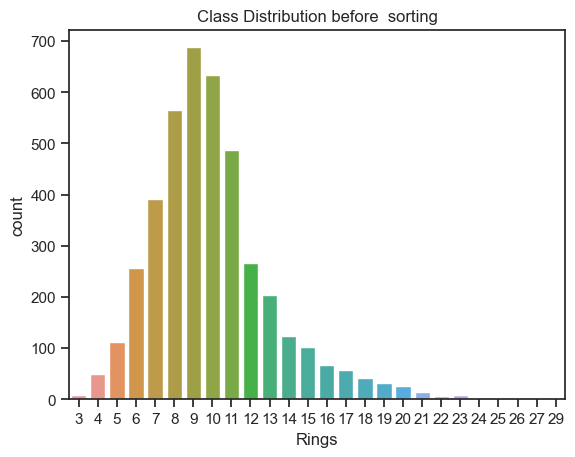

,Original_Rings,Binned_Category
520,3,1
44,4,1
42,5,1
48,6,1
1,7,1
5,8,1
2,9,2
3,10,3
12,11,4
15,12,4


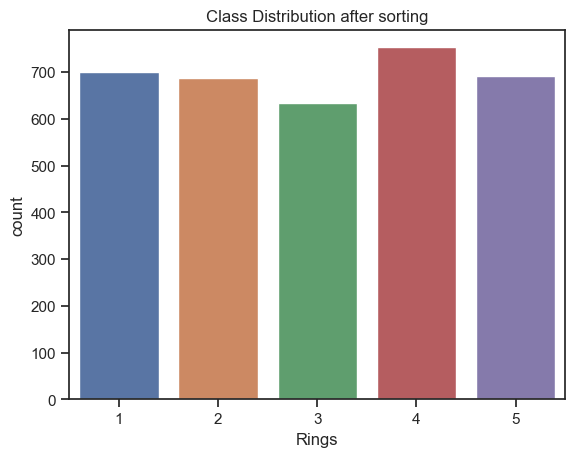

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Sex_F,Sex_I,Sex_M
3587,0.635,0.495,0.170,1.3695,0.6570,0.3055,0.3650,3,0.0,0.0,1.0
2238,0.460,0.335,0.110,0.4440,0.2250,0.0745,0.1100,1,0.0,1.0,0.0
3757,0.520,0.410,0.140,0.6990,0.3395,0.1290,0.1945,3,0.0,1.0,0.0
1349,0.590,0.455,0.155,0.8855,0.3880,0.1880,0.2750,3,0.0,0.0,1.0
752,0.605,0.460,0.170,1.1220,0.3470,0.3045,0.3150,5,1.0,0.0,0.0
1956,0.645,0.490,0.175,1.3200,0.6525,0.2375,0.3385,4,0.0,0.0,1.0
795,0.515,0.405,0.145,0.6950,0.2150,0.1635,0.2340,5,0.0,0.0,1.0
2591,0.585,0.450,0.160,0.9045,0.4050,0.2215,0.2335,1,1.0,0.0,0.0
364,0.620,0.500,0.175,1.1860,0.4985,0.3015,0.3500,4,1.0,0.0,0.0
2570,0.465,0.355,0.110,0.4740,0.2300,0.1005,0.1200,1,0.0,1.0,0.0


'after normalizing'

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight
count,3.465000e+03,3.465000e+03,3.465000e+03,3.465000e+03,3.465000e+03,3.465000e+03,3.465000e+03
mean,-1.332908e-17,1.297022e-16,2.296704e-16,1.179111e-16,-1.394427e-16,-1.240630e-16,2.101894e-16
std,1.000144e+00,1.000144e+00,1.000144e+00,1.000144e+00,1.000144e+00,1.000144e+00,1.000144e+00
min,-3.746380e+00,-3.554777e+00,-2.986311e+00,-1.868176e+00,-1.770524e+00,-1.824075e+00,-1.901533e+00
25%,-5.964770e-01,-5.647777e-01,-5.950781e-01,-7.585919e-01,-7.739024e-01,-7.506842e-01,-7.216781e-01
50%,1.795860e-01,1.550370e-01,1.082255e-01,-4.289948e-02,-7.672468e-02,-6.464725e-02,-2.113907e-02
75%,7.273952e-01,7.087406e-01,6.708685e-01,6.498072e-01,6.318822e-01,6.493912e-01,6.093460e-01
max,2.325172e+00,2.259111e+00,2.640119e+00,4.003636e+00,5.009244e+00,4.135579e+00,5.472562e+00


In [3]:
print(f'Data: shape={abalone[D].shape}')
display("describe",abalone[D].describe())
display("skew:",abalone[D].skew())
display("kurtosis", abalone[D].kurtosis())
display("variance", abalone[D].std())

feature_range = abalone[D].max() - abalone[D].min()
display("range:")
display(feature_range)


sns.histplot(abalone['Height'], bins=30, kde=True)  
plt.title("Height Feature Distribution")
plt.show()

Q1 = abalone['Height'].quantile(0.25)
Q3 = abalone['Height'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
abalone = abalone[(abalone['Height'] >= lower_bound) & (abalone['Height'] <= upper_bound)]
print(f'Data: shape after removing outliers={abalone[D].shape}')

subset = ['Length', 'Diameter', 'Height']
sns.pairplot(abalone[subset])
plt.show()

sns.countplot(x =abalone[C])
plt.title("Class Distribution")
plt.show()

sns.countplot(x = abalone[C])
plt.title("Class Distribution before  sorting")
plt.show()


X = abalone[DL]
y = abalone[C]
#splitting the target variable into buckets to make it a balanced classification problem
value_counts = y.value_counts().sort_index()
cumulative_counts = value_counts.cumsum()
total_samples = cumulative_counts.max()
num_buckets = 5

percentiles = np.linspace(0, 1, num_buckets + 1)  # Create bin edges
bin_edges = np.percentile(y, percentiles * 100) #find boundaries
bin_labels = range(1, num_buckets + 1)

y_bucket = pd.cut(y, bins=bin_edges, labels=range(1, num_buckets + 1), include_lowest=True)

ring_to_category = pd.DataFrame({'Original_Rings': y, 'Binned_Category': y_bucket})
ring_to_category = ring_to_category.drop_duplicates().sort_values(by='Original_Rings')
display(ring_to_category)

class_1_subset = X[y_bucket == 1]
class_1_subset_y = y_bucket[y_bucket == 1] 
class_1_indices = y_bucket[y_bucket == 1].index  # Get indices of class 1
other_class_indices = y_bucket[y_bucket != 1].index  # Get indices of other classes
class_1_sampled_indices = np.random.choice(class_1_indices, size=700, replace=False) 
final_indices = np.concatenate([class_1_sampled_indices, other_class_indices])


X = X.loc[final_indices] 
y = y_bucket.loc[final_indices] 

abalone = pd.concat([X, y], axis=1)
abalone = shuffle(abalone, random_state=42)

sns.countplot(x=abalone[C])
plt.title("Class Distribution after sorting")
plt.show()

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_features = encoder.fit_transform(abalone[L])
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(L), index=abalone.index)
# Drop categorical columns and replace with encoded ones
abalone = abalone.drop(columns=L).join(encoded_df)

scaler = StandardScaler()
#standardize everything except target variable and one-hot-encoding
numeric_features = abalone.columns[0:-4]
abalone[numeric_features] = scaler.fit_transform(abalone[numeric_features])

display("after normalizing",abalone[D].describe())

X = abalone[D + list(encoded_df.columns)]
y = abalone[C]


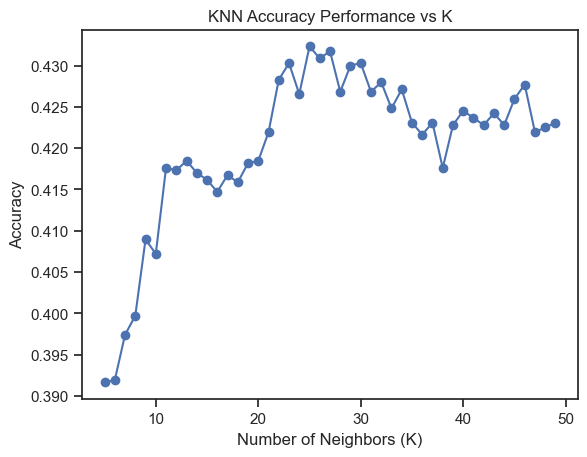

In [4]:
#KNN classification
k_performance = {}

for k in range(5, 50):
    

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    accuracies = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracies.append(accuracy_score(y_test, y_pred))
        
    k_performance[k] = np.mean(accuracies)

plt.plot(k_performance.keys(), k_performance.values(), marker='o')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy') 
plt.title('KNN Accuracy Performance vs K')
plt.show()


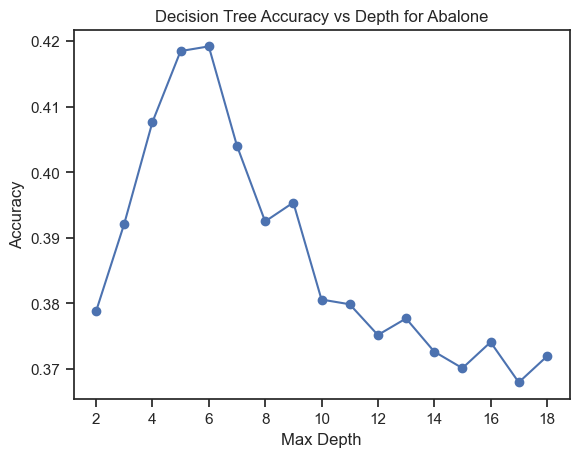

In [18]:
#Decision Tree Classifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

param_grid = {'max_depth': range(2, 19)}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=cv, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_
y_pred = best_tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

plt.figure()
plt.plot(param_grid['max_depth'], grid_search.cv_results_['mean_test_score'], marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title(f'Decision Tree Accuracy vs Depth for Abalone')
plt.show()

In [23]:
from sklearn.tree import plot_tree, export_text, export_graphviz

# Interpretability
tree_rules = export_text(best_tree, feature_names=list(X_train.columns))
with open(f"decision_tree_rules_abalone.txt", "w") as f:
    f.write(tree_rules)

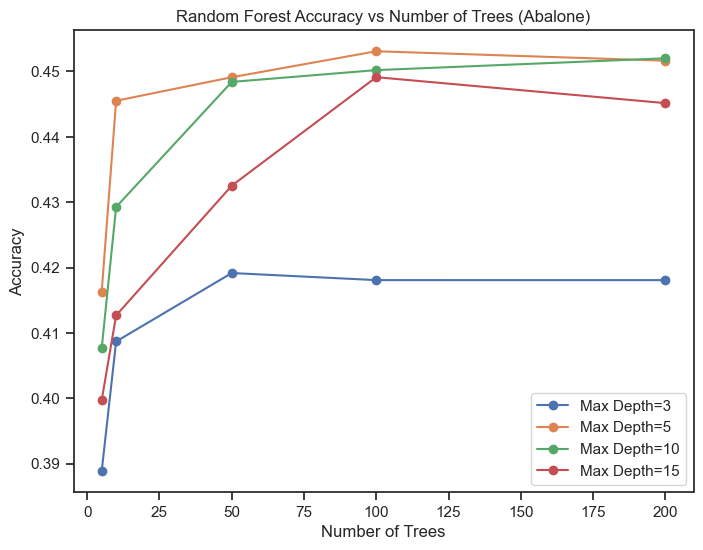

In [26]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

param_grid = {'max_depth': [3, 5, 10, 15], 'n_estimators': [5, 10, 50, 100, 200]}
cv = KFold(n_splits=5, shuffle=True)

grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=cv, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

scores_matrix = np.array(grid_search.cv_results_['mean_test_score']).reshape(len(param_grid['max_depth']), len(param_grid['n_estimators']))

plt.figure(figsize=(8, 6))
for i, depth in enumerate(param_grid['max_depth']):
    plt.plot(param_grid['n_estimators'], scores_matrix[i, :], marker='o', label=f'Max Depth={depth}')

plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy vs Number of Trees (Abalone)')
plt.legend()
plt.show()


In [7]:
#Summarize Results